In [34]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
from dotenv import load_dotenv
from scipy.io import loadmat
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split

load_dotenv()
DATASET = os.getenv('DATASET_PATH')

In [28]:
data = []

for num, img_path in enumerate(mat_data['file_list']):
    data.append({
        'img_path': f'{DATASET}/images/{str(img_path[0][0])}',
        'annotation_path': f'{DATASET}/annotation/{mat_data['annotation_list'][num][0][0]}',
        'label': mat_data['labels'][num][0]
    })

df = pd.DataFrame(data)
print(len(df['img_path']), len(df['annotation_path']), len(df['label']))

20580 20580 20580


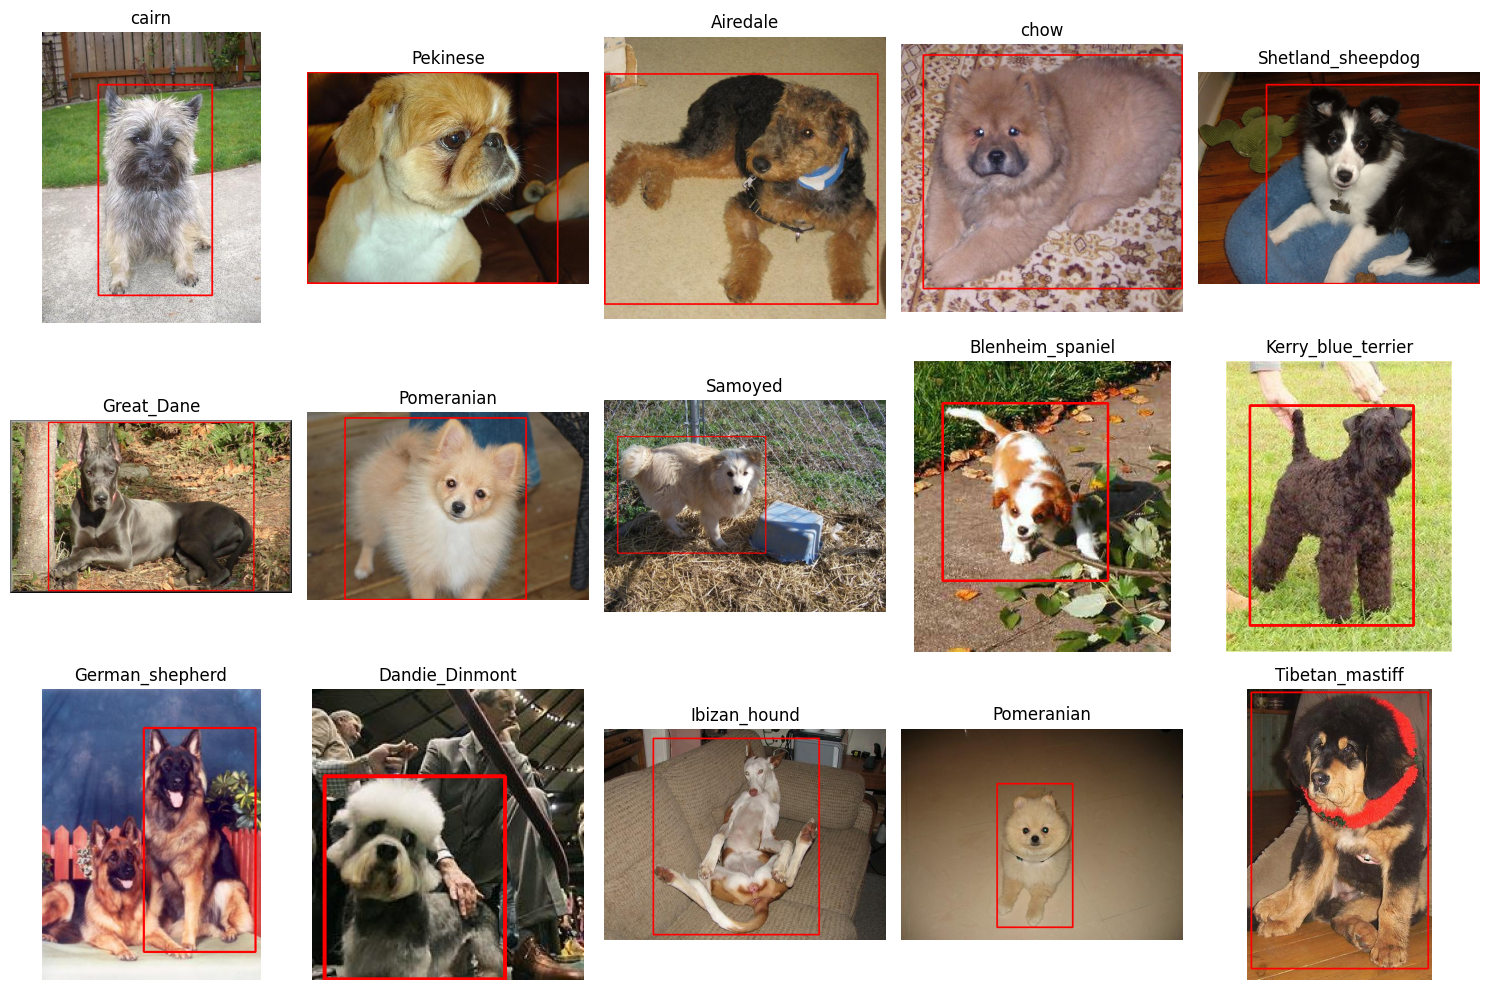

In [42]:
def get_bbox(annotation_path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    bndbox = root.find('.//bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)
    return xmin, ymin, xmax, ymax


plt.figure(figsize=(15, 10))

for ii in range(15):
    idx = np.random.randint(0, num_samples)

    img = cv2.imread(df.iloc[idx]['img_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    xmin, ymin, xmax, ymax = get_bbox(df.iloc[idx]['annotation_path'])
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color=(255, 0, 0), thickness=2)

    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(df.iloc[idx]['annotation_path'].split('/')[-2].split('-')[1])
    plt.axis('off')

plt.tight_layout()
plt.show()

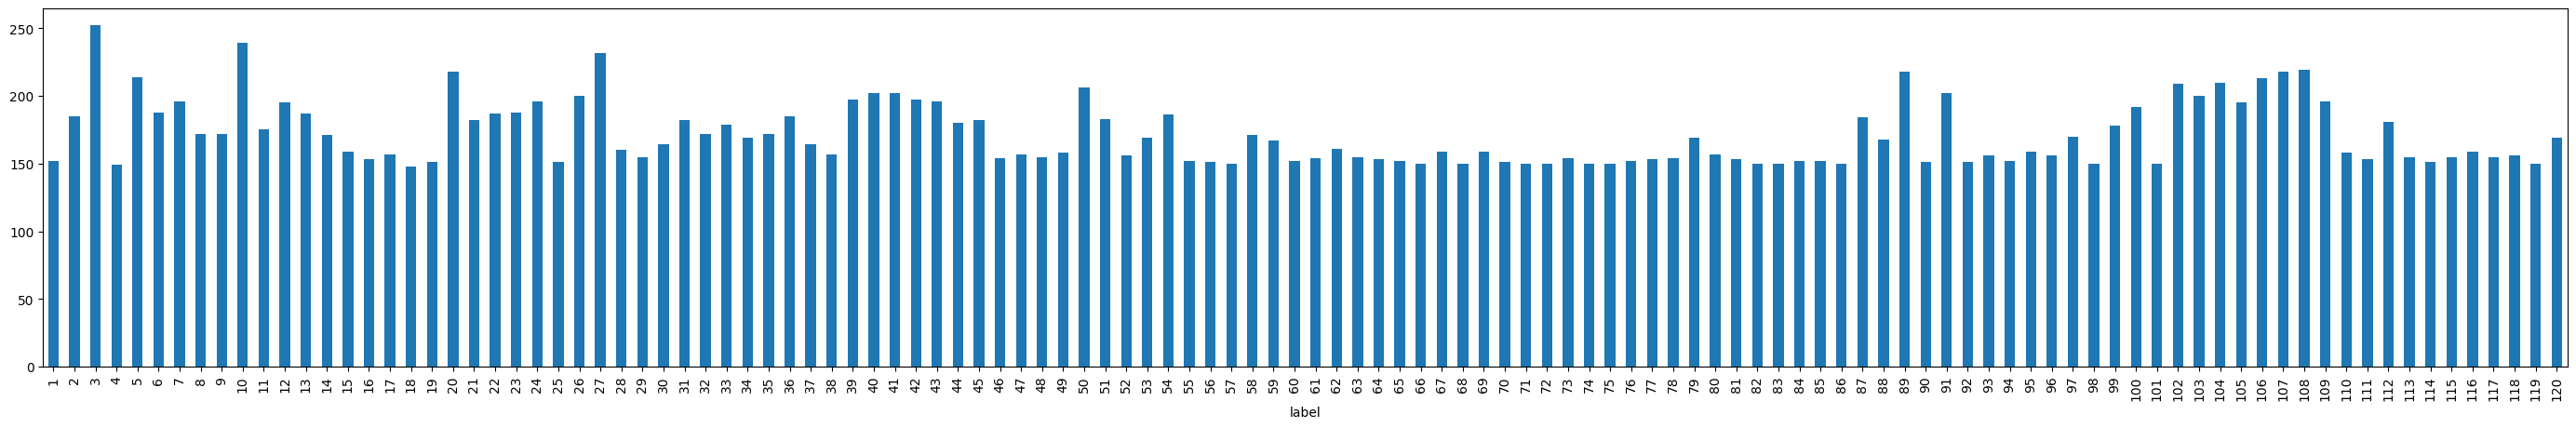

In [30]:
# class balance

df['label'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(35,5)
)
plt.show()

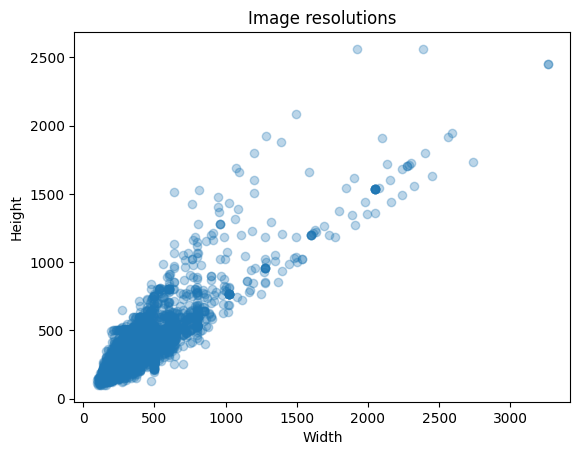

In [53]:
# resolution disribution

sizes = []

for path in df['img_path']:
    with Image.open(f'{DATASET}/images/{path}') as img:
        sizes.append(img.size)

sizes = np.array(sizes)

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.3)
plt.xlabel('Width'), plt.ylabel('Height')
plt.title('Image resolutions')
plt.show()

In [35]:
# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)


# 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(len(train_df), len(val_df), len(test_df))

14406 3087 3087
